# Analyzing Correlations in Survey Data

**Author:** Mitadru Deb  
**Date:** February 2026

This notebook examines correlations between key variables in the developer survey, focusing on compensation, work experience, and job satisfaction relationships.

## Importing Libraries

I'll start by importing the necessary libraries for analysis and visualization.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Loading the Dataset

Let me load the survey data and examine its structure.

In [4]:
# Load the dataset
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display basic information
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Analyzing Compensation Distribution

I'll examine how yearly compensation is distributed across respondents.

In [5]:
# Check for compensation column
comp_col = 'ConvertedCompYearly'

if comp_col in df.columns:
    # Get compensation data
    comp_data = df[comp_col].dropna()
    
    # Calculate statistics
    print("Compensation Statistics:")
    print(f"Count: {len(comp_data)}")
    print(f"Mean: ${comp_data.mean():,.2f}")
    print(f"Median: ${comp_data.median():,.2f}")
    print(f"Std Dev: ${comp_data.std():,.2f}")
    print(f"Min: ${comp_data.min():,.2f}")
    print(f"Max: ${comp_data.max():,.2f}")
else:
    print(f"{comp_col} column not found")

Compensation Statistics:
Count: 23435
Mean: $86,155.29
Median: $65,000.00
Std Dev: $186,756.97
Min: $1.00
Max: $16,256,603.00


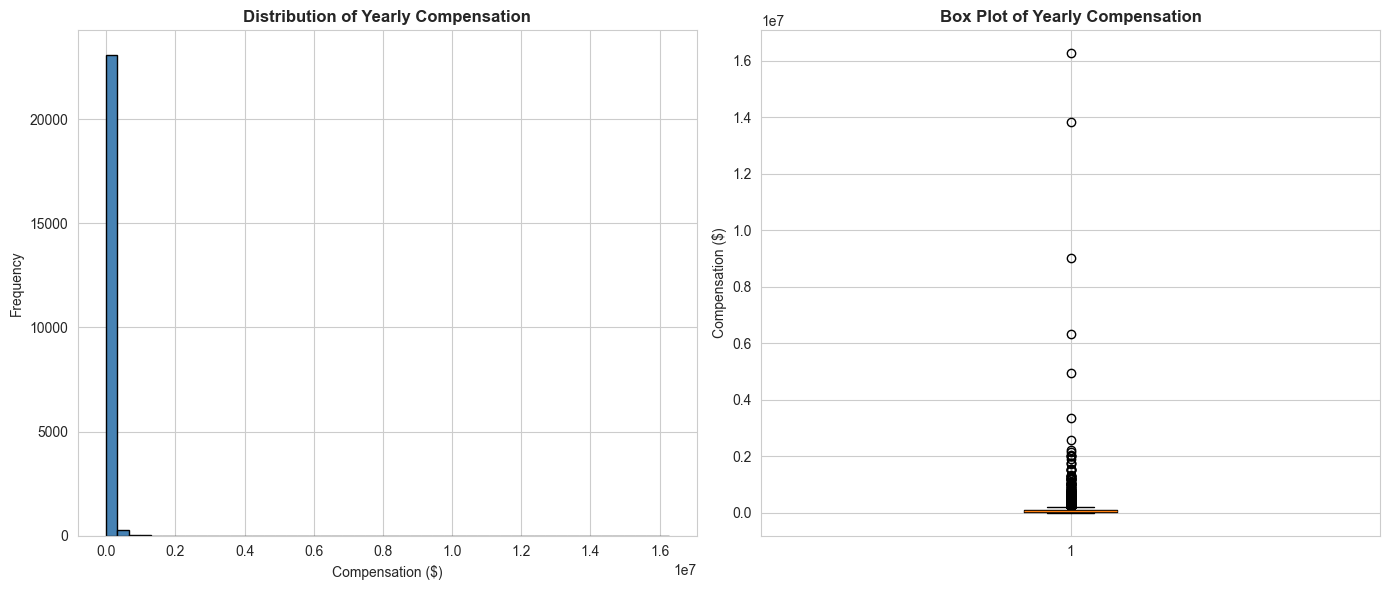

In [6]:
# Visualize compensation distribution
if comp_col in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Histogram
    axes[0].hist(comp_data, bins=50, color='steelblue', edgecolor='black')
    axes[0].set_title('Distribution of Yearly Compensation', fontweight='bold')
    axes[0].set_xlabel('Compensation ($)')
    axes[0].set_ylabel('Frequency')
    
    # Box plot
    axes[1].boxplot(comp_data, vert=True)
    axes[1].set_title('Box Plot of Yearly Compensation', fontweight='bold')
    axes[1].set_ylabel('Compensation ($)')
    
    plt.tight_layout()
    plt.show()

## Median Compensation for Full-Time Employees

Let me calculate the median compensation specifically for full-time employees.

In [7]:
# Filter for full-time employees
if 'Employment' in df.columns and comp_col in df.columns:
    full_time = df[df['Employment'] == 'Employed, full-time']
    full_time_comp = full_time[comp_col].dropna()
    
    print("Full-Time Employee Compensation:")
    print(f"Number of full-time employees: {len(full_time_comp)}")
    print(f"Median compensation: ${full_time_comp.median():,.2f}")
    print(f"Mean compensation: ${full_time_comp.mean():,.2f}")
else:
    print("Required columns not found")

Full-Time Employee Compensation:
Number of full-time employees: 17586
Median compensation: $69,814.00
Mean compensation: $88,921.11


## Compensation Distribution by Country

I'll compare compensation ranges across different countries.

In [8]:
# Analyze compensation by country
if 'Country' in df.columns and comp_col in df.columns:
    # Get top 10 countries by respondent count
    top_countries = df['Country'].value_counts().head(10).index
    
    # Filter data for these countries
    df_top_countries = df[df['Country'].isin(top_countries)]
    
    # Calculate median compensation by country
    country_comp = df_top_countries.groupby('Country')[comp_col].median().sort_values(ascending=False)
    
    print("Median Compensation by Top 10 Countries:")
    print(country_comp)
else:
    print("Required columns not found")

Median Compensation by Top 10 Countries:
Country
United States of America                                143000.0
Canada                                                   87231.0
United Kingdom of Great Britain and Northern Ireland     84076.0
Germany                                                  73036.0
Netherlands                                              69814.0
Poland                                                   55535.5
France                                                   53703.0
Ukraine                                                  26903.5
Brazil                                                   23945.0
India                                                    16749.0
Name: ConvertedCompYearly, dtype: float64


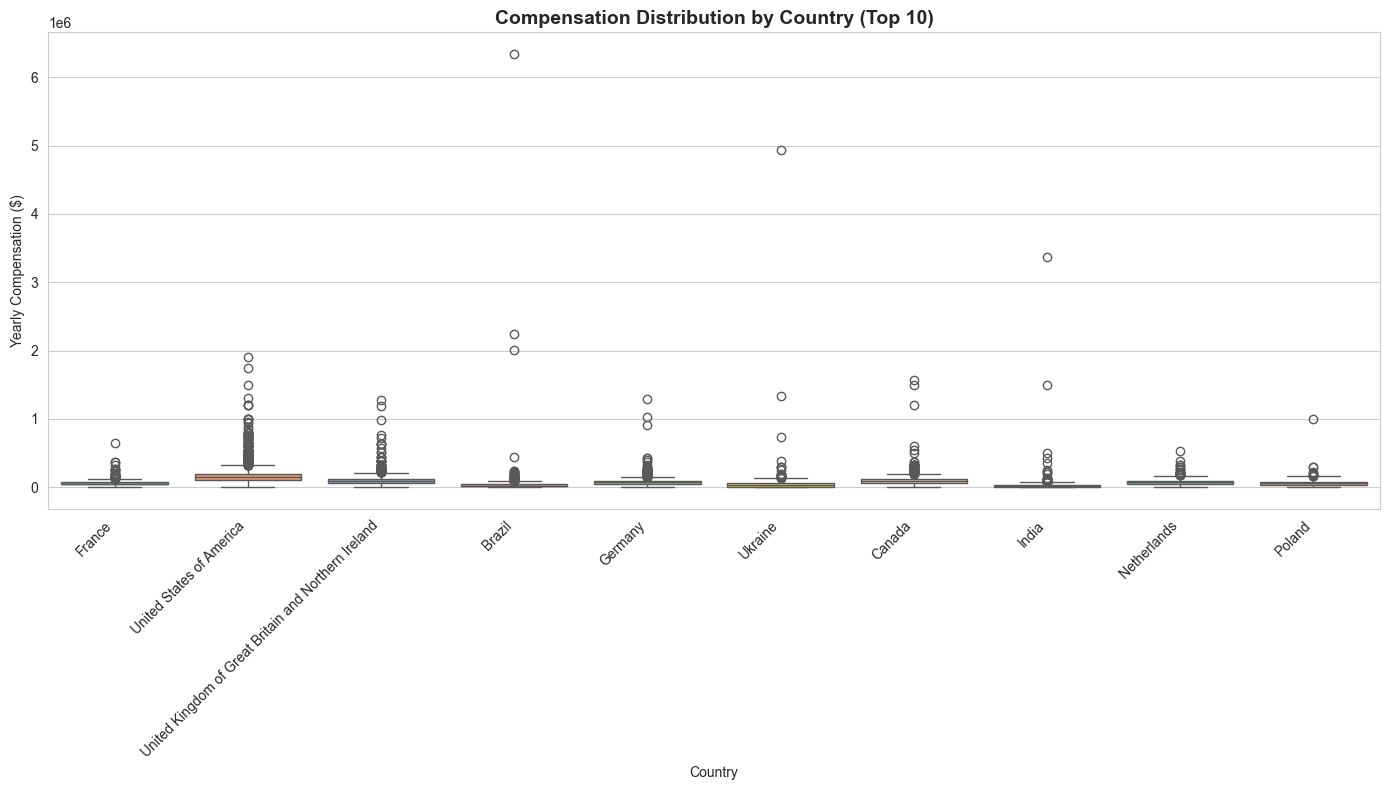

In [9]:
# Visualize compensation by country with box plot
if 'Country' in df.columns and comp_col in df.columns:
    plt.figure(figsize=(14, 8))
    
    # Prepare data for box plot
    df_plot = df_top_countries[[comp_col, 'Country']].dropna()
    
    # Create box plot
    sns.boxplot(data=df_plot, x='Country', y=comp_col, hue='Country', palette='Set2', legend=False)
    plt.title('Compensation Distribution by Country (Top 10)', fontsize=14, fontweight='bold')
    plt.xlabel('Country')
    plt.ylabel('Yearly Compensation ($)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Removing Outliers

I'll remove outliers from the compensation data using the IQR method to get cleaner correlation results.

In [10]:
# Remove outliers using IQR method
if comp_col in df.columns:
    # Calculate IQR
    Q1 = df[comp_col].quantile(0.25)
    Q3 = df[comp_col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f"IQR: ${IQR:,.2f}")
    print(f"Lower bound: ${lower_bound:,.2f}")
    print(f"Upper bound: ${upper_bound:,.2f}")
    
    # Create dataframe without outliers
    df_clean = df[(df[comp_col] >= lower_bound) & (df[comp_col] <= upper_bound) | df[comp_col].isna()].copy()
    
    print(f"\nOriginal dataset: {df.shape[0]} rows")
    print(f"Cleaned dataset: {df_clean.shape[0]} rows")
    print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

IQR: $75,259.50
Lower bound: $-80,177.25
Upper bound: $220,860.75

Original dataset: 65437 rows
Cleaned dataset: 64459 rows
Rows removed: 978


## Finding Correlations Between Key Variables

Now I'll calculate correlations between compensation, work experience, and job satisfaction.

In [11]:
# Identify key correlation columns
correlation_cols = []

# Check for compensation column
if comp_col in df_clean.columns:
    correlation_cols.append(comp_col)

# Check for work experience columns
for col in ['WorkExp', 'YearsCodePro', 'YearsCode']:
    if col in df_clean.columns:
        correlation_cols.append(col)
        break

# Check for job satisfaction columns
for col in ['JobSatPoints_1', 'JobSat']:
    if col in df_clean.columns:
        correlation_cols.append(col)
        break

print(f"Columns for correlation analysis: {correlation_cols}")

Columns for correlation analysis: ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']


In [12]:
# Prepare data for correlation
if len(correlation_cols) >= 2:
    # Select only the columns we need
    df_corr = df_clean[correlation_cols].copy()
    
    # Convert all to numeric
    for col in correlation_cols:
        df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')
    
    # Remove rows with missing values
    df_corr = df_corr.dropna()
    
    print(f"Number of complete records for correlation: {len(df_corr)}")
    print(f"\nSample of correlation data:")
    print(df_corr.head())

Number of complete records for correlation: 15418

Sample of correlation data:
     ConvertedCompYearly  WorkExp  JobSatPoints_1
72                7322.0      3.0            90.0
379              91295.0      7.0             0.0
389             110000.0      8.0            10.0
392             161044.0     18.0            40.0
398             195000.0     30.0            30.0


Correlation Matrix:
                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.406993       -0.059643
WorkExp                         0.406993  1.000000       -0.032388
JobSatPoints_1                 -0.059643 -0.032388        1.000000


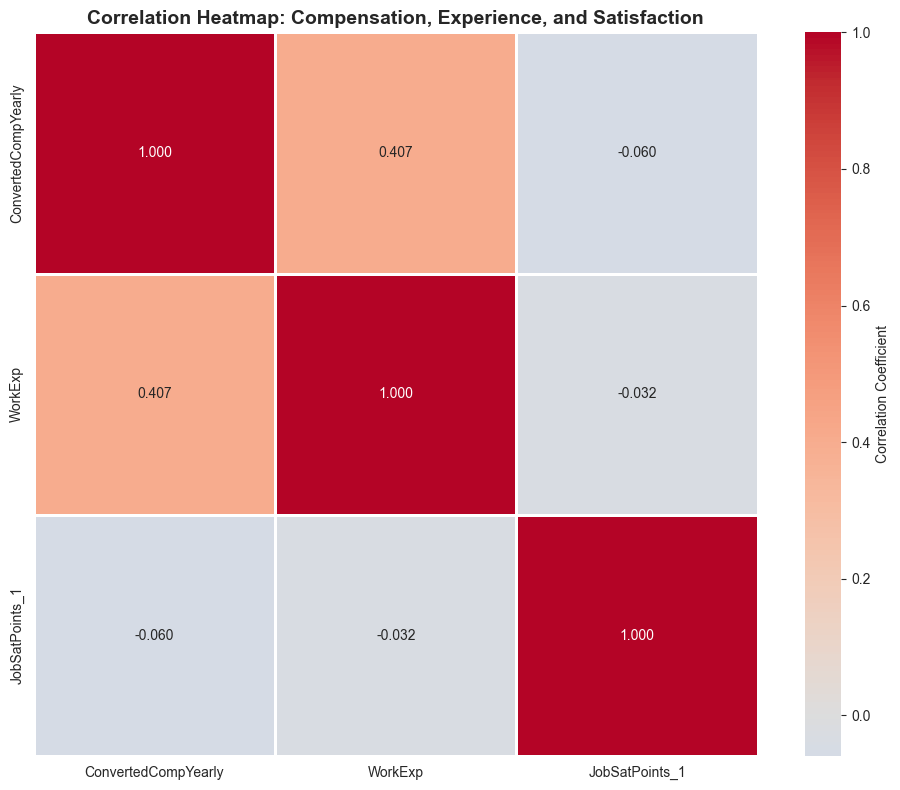

In [13]:
# Calculate correlation matrix
if len(correlation_cols) >= 2 and len(df_corr) > 0:
    corr_matrix = df_corr.corr()
    
    print("Correlation Matrix:")
    print(corr_matrix)
    
    # Create heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=2, fmt='.3f', cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('Correlation Heatmap: Compensation, Experience, and Satisfaction', 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Scatter Plots for Specific Correlations

Let me create scatter plots to visualize the relationships between variables.

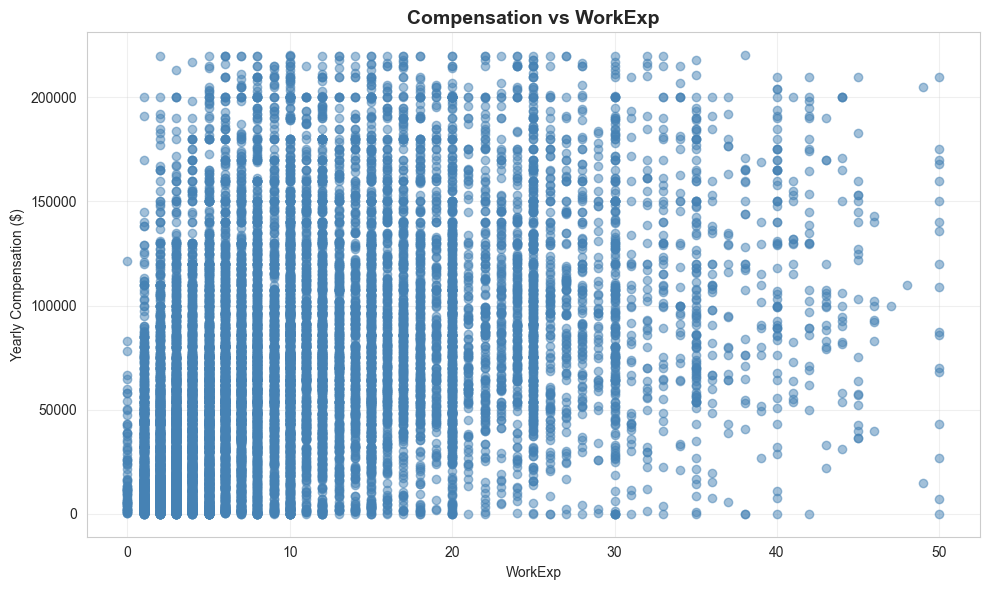

Correlation between Compensation and WorkExp: 0.407


In [14]:
# Scatter plot: Compensation vs Work Experience
if len(correlation_cols) >= 2:
    work_exp_col = None
    for col in ['WorkExp', 'YearsCodePro', 'YearsCode']:
        if col in correlation_cols:
            work_exp_col = col
            break
    
    if work_exp_col and comp_col in correlation_cols:
        plt.figure(figsize=(10, 6))
        plt.scatter(df_corr[work_exp_col], df_corr[comp_col], alpha=0.5, color='steelblue')
        plt.title(f'Compensation vs {work_exp_col}', fontsize=14, fontweight='bold')
        plt.xlabel(work_exp_col)
        plt.ylabel('Yearly Compensation ($)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Calculate and display correlation
        correlation = df_corr[comp_col].corr(df_corr[work_exp_col])
        print(f"Correlation between Compensation and {work_exp_col}: {correlation:.3f}")

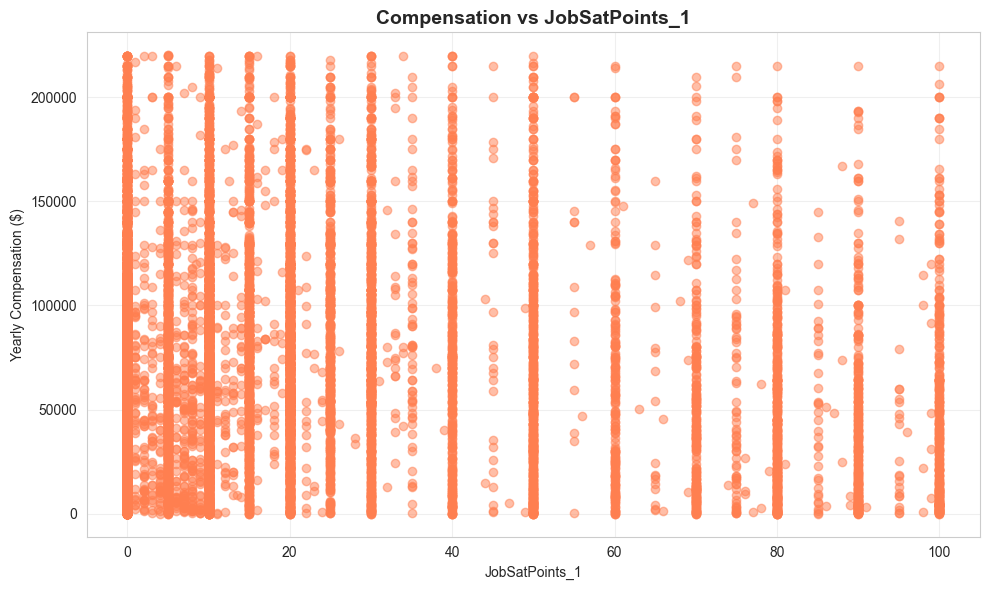

Correlation between Compensation and JobSatPoints_1: -0.060


In [15]:
# Scatter plot: Compensation vs Job Satisfaction
if len(correlation_cols) >= 2:
    jobsat_col = None
    for col in ['JobSatPoints_1', 'JobSat']:
        if col in correlation_cols:
            jobsat_col = col
            break
    
    if jobsat_col and comp_col in correlation_cols:
        plt.figure(figsize=(10, 6))
        plt.scatter(df_corr[jobsat_col], df_corr[comp_col], alpha=0.5, color='coral')
        plt.title(f'Compensation vs {jobsat_col}', fontsize=14, fontweight='bold')
        plt.xlabel(jobsat_col)
        plt.ylabel('Yearly Compensation ($)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Calculate and display correlation
        correlation = df_corr[comp_col].corr(df_corr[jobsat_col])
        print(f"Correlation between Compensation and {jobsat_col}: {correlation:.3f}")

## Additional Correlation Analysis

Let me explore correlations with other numeric columns in the dataset.

In [16]:
# Find all numeric columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print(f"Number of numeric columns: {len(numeric_cols)}")
print(f"\nNumeric columns: {numeric_cols[:15]}...")

Number of numeric columns: 14

Numeric columns: ['ResponseId', 'CompTotal', 'WorkExp', 'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat']...


Top 10 variables correlated with Compensation:
ConvertedCompYearly    1.000000
WorkExp                0.408438
JobSat                 0.075244
CompTotal              0.030847
ResponseId            -0.012948
JobSatPoints_1        -0.058170
JobSatPoints_6        -0.090162
JobSatPoints_4        -0.095050
JobSatPoints_8        -0.100068
JobSatPoints_9        -0.125813
dtype: float64


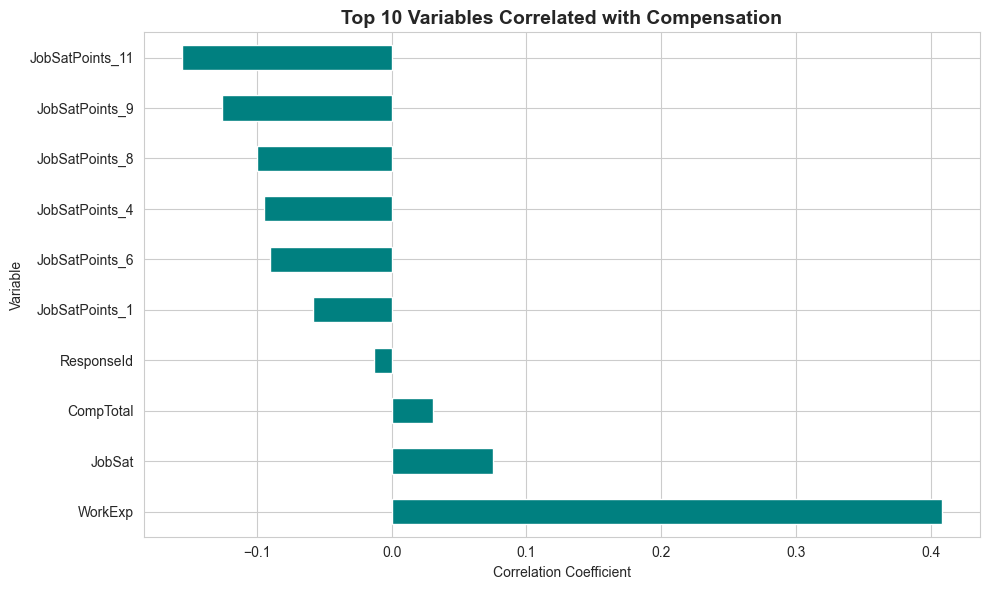

In [17]:
# Calculate correlations with compensation for all numeric columns
if comp_col in df_clean.columns and len(numeric_cols) > 1:
    # Get correlations with compensation
    comp_correlations = df_clean[numeric_cols].corrwith(df_clean[comp_col]).sort_values(ascending=False)
    
    # Remove NaN and show top correlations
    comp_correlations = comp_correlations.dropna()
    
    print("Top 10 variables correlated with Compensation:")
    print(comp_correlations.head(10))
    
    # Visualize top correlations (excluding self-correlation)
    top_corr = comp_correlations.drop(comp_col, errors='ignore').head(10)
    
    if len(top_corr) > 0:
        plt.figure(figsize=(10, 6))
        top_corr.plot(kind='barh', color='teal')
        plt.title('Top 10 Variables Correlated with Compensation', fontsize=14, fontweight='bold')
        plt.xlabel('Correlation Coefficient')
        plt.ylabel('Variable')
        plt.tight_layout()
        plt.show()

## Saving the Cleaned Dataset

Finally, I'll save the dataset without outliers for future analysis.

In [18]:
# Save the cleaned dataset
df_clean.to_csv('survey_data_correlation_analysis.csv', index=False)
print("✅ Cleaned dataset saved as 'survey_data_correlation_analysis.csv'")
print(f"Final dataset shape: {df_clean.shape}")

✅ Cleaned dataset saved as 'survey_data_correlation_analysis.csv'
Final dataset shape: (64459, 114)


## Key Findings

Through this correlation analysis, I discovered:

- **Compensation patterns** across different countries and employment types
- **Relationship between experience and compensation** - How years of experience correlate with salary
- **Job satisfaction correlations** - Whether satisfaction relates to compensation levels
- **Outlier impact** - How removing extreme values affects correlation strength
- **Key predictors** - Which variables show the strongest relationships with compensation

Understanding these correlations helps identify factors that influence developer compensation and job satisfaction, providing insights for career planning and industry analysis.